# **Classification Models with Keras**

In this lab, we will learn how to use the Keras library to build models for classification problems. We will use the popular MNIST dataset, a dataset of images, for a change.

The <strong>MNIST database</strong>, short for Modified National Institute of Standards and Technology database, is a large database of handwritten digits that is commonly used for training various image processing systems.he database is also widely used for training and testing in the field of machine learning.
    
The MNIST database contains 60,000 training images and 10,000 testing images of digits written by high school students and employees of the United States Census Bureau.

Also, this way, will be able to check how conventional neural networks compare to convolutional neural networks, that we will build in the next module.

## **Import Keras and Packages**

In [ ]:
import tensorflow

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

Since we are dealing we images, let's also import the Matplotlib scripting layer in order to view the images.

In [ ]:
import matplotlib.pyplot as plt

The Keras library conveniently includes the MNIST dataset as part of its API. You can check other datasets within the Keras library [here](https://keras.io/datasets/). So, let's load the MNIST dataset from the Keras library. The dataset is readily divided into a training set and a test set.

In [ ]:
# import the data
from tensorflow.keras.datasets import mnist

# read the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11501568/11490434 [==============================] - 0s 0us/step


Let's confirm the number of images in each set. According to the dataset's documentation, we should have 60000 images in X_train and 10000 images in the X_test.

In [ ]:
print(X_train.shape)
# JG:
print("X_train.dtype: ", X_train.dtype)
print("X_train.ndim: ", X_train.ndim)
print("type of X_train: ", type(X_train))

(60000, 28, 28)
X_train.dtype:  uint8
X_train.ndim:  3
type of X_train:  <class 'numpy.ndarray'>


The first number is the output tuple is the number of images, and the other two numbers are the size of the images in datset. So, each image is 28 pixels by 28 pixels.

Let's visualize the first 2 images in the training set using Matplotlib's scripting layer.

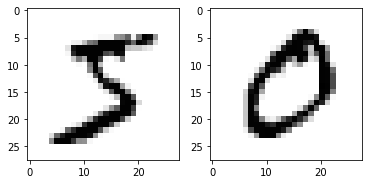

In [ ]:
import matplotlib.pyplot as plt

plt.subplot(1,2,1)
plt.imshow(X_train[0,:,:], cmap= 'Greys')
plt.subplot(1,2,2)
plt.imshow(X_train[1,:,:], cmap= 'Greys')

The labels corresponding to this two images are:

In [ ]:
# print the corresponding class for the first two training images
print(y_train.shape)
print(y_train[0])
print(y_train[1])

(60000,)
5
0


With conventional neural networks, we cannot feed in the image as input as is. So we need to flatten the images into one-dimensional vectors, each of size 1 x (28 x 28) = 1 x 784.

In [ ]:
# flatten images into one-dimensional vector
num_pixels = X_train.shape[1] * X_train.shape[2] # find size of one-dimensional vector
print(num_pixels)
# JG: this rises error if consecutive executions are run (once X_train has been flattened)
# so, better just do:
X_train_flatten = X_train.reshape(X_train.shape[0], num_pixels).astype('float32') # flatten training images # X_train_flatten = X_train.reshape(60000,784)
print(X_train_flatten.shape)
X_test_flatten = X_test.reshape(X_test.shape[0], num_pixels).astype('float32') # flatten test images
print(X_test_flatten.shape)

784
(60000, 784)
(10000, 784)


Since pixel values can range from 0 to 255, let's normalize the vectors to be between 0 and 1.


In [ ]:
# normalize inputs from 0-255 to 0-1
x_train_flatten = X_train_flatten / 255
x_test_flatten = X_test_flatten / 255

Finally, before we start building our model, remember that for classification we need to divide our target variable into categories. We use the to_categorical function from the Keras Utilities package.

In [ ]:
# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print(y_train.shape)
print(y_test.shape)
# so, for the first two images, che corresponding classes "5" and "0" are now encoded as:
print(y_train[0,:])
print(y_train[1,:])

num_classes = y_test.shape[1]
print(num_classes)

(60000, 10)
(10000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
10


## **Buil Neural Network**

In [ ]:
# define classification model
def classification_model():
    # create model
    model = Sequential()
    model.add(Dense(200, activation='relu', input_shape=(num_pixels,)))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(20, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))


    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

Below is a list of the metrics that you can use in Keras on classification problems.

    Binary Accuracy: binary_accuracy, acc
    Categorical Accuracy: categorical_accuracy, acc
    Sparse Categorical Accuracy: sparse_categorical_accuracy
    Top k Categorical Accuracy: top_k_categorical_accuracy (requires you specify a k parameter)
    Sparse Top k Categorical Accuracy: sparse_top_k_categorical_accuracy (requires you specify a k parameter)

Accuracy is special. Regardless of whether your problem is a binary or multi-class classification problem, you can specify the ‘acc‘ metric to report on accuracy.

Check this [link](https://machinelearningmastery.com/custom-metrics-deep-learning-keras-python/) for more information on built-in regresion metrics, classification metrics, and how to define custom metrics on keras.


**DISEÑO ARQUITECTURA**

Diseñar la arquitectura de una red neuronal depende de varios factores, y no hay una respuesta única ya que es parte de un proceso experimental conocido como "model selection". Sin embargo, hay ciertas pautas y consideraciones generales que puedes seguir:

- Tipo de problema: La elección de la arquitectura depende del tipo de problema. Para la clasificación de imágenes, las redes neuronales convolucionales (CNN) son comúnmente usadas.

- Complejidad del problema: Cuanto más complejo sea el problema, es posible que necesites una red más profunda con más capas para capturar características más abstractas.

- Tamaño y naturaleza de los datos: Si tienes imágenes de alta resolución y muchos datos de entrenamiento, puedes permitirte una red más compleja sin tanto riesgo de sobreajuste. Para imágenes más pequeñas o menos datos, es posible que necesites una red más pequeña.

- Potencia computacional: Las redes más grandes requieren más potencia de cómputo y más tiempo para entrenar.

- Investigaciones previas: A menudo, es útil ver qué arquitecturas han funcionado bien para problemas similares y comenzar con eso como punto de partida.

## **Train and Test Network**

In [ ]:


# build the model
model = classification_model()

# fit the model
# model.fit(X_train_flatten, y_train, validation_data=(X_test_flatten, y_test), epochs=10, verbose=2)

history = model.fit(X_train_flatten, y_train, validation_split=0.2, epochs=20, verbose=2)


Epoch 1/20
1500/1500 - 11s - loss: 1.4789 - accuracy: 0.5849 - val_loss: 0.8885 - val_accuracy: 0.6989 - 11s/epoch - 8ms/step
Epoch 2/20
1500/1500 - 5s - loss: 0.6253 - accuracy: 0.8276 - val_loss: 0.3529 - val_accuracy: 0.9145 - 5s/epoch - 3ms/step
Epoch 3/20
1500/1500 - 5s - loss: 0.2894 - accuracy: 0.9265 - val_loss: 0.2188 - val_accuracy: 0.9443 - 5s/epoch - 3ms/step
Epoch 4/20
1500/1500 - 5s - loss: 0.2062 - accuracy: 0.9463 - val_loss: 0.2049 - val_accuracy: 0.9472 - 5s/epoch - 3ms/step
Epoch 5/20
1500/1500 - 5s - loss: 0.1496 - accuracy: 0.9596 - val_loss: 0.1648 - val_accuracy: 0.9579 - 5s/epoch - 3ms/step
Epoch 6/20
1500/1500 - 5s - loss: 0.1238 - accuracy: 0.9660 - val_loss: 0.1829 - val_accuracy: 0.9559 - 5s/epoch - 3ms/step
Epoch 7/20
1500/1500 - 5s - loss: 0.1001 - accuracy: 0.9728 - val_loss: 0.1504 - val_accuracy: 0.9648 - 5s/epoch - 3ms/step
Epoch 8/20
1500/1500 - 5s - loss: 0.0865 - accuracy: 0.9763 - val_loss: 0.1496 - val_accuracy: 0.9645 - 5s/epoch - 3ms/step
Epoch 

Let's print the accuracy and the corresponding error.

In [ ]:
# evaluate the model
scores = model.evaluate(X_test_flatten, y_test, verbose=0)
print(model.metrics_names) # from the .evaluate method doc we know .metric_names
# stores the labels for the metrics used
print(scores)
print(f"Accuracy: {scores[1]*100}% \nError: {100 - scores[1]*100}%")

['loss', 'accuracy']
[0.13831466436386108, 0.9771000146865845]
Accuracy: 97.71000146865845% 
Error: 2.2899985313415527%


In [ ]:
history.history

{'accuracy': [0.5849375128746033,
  0.8276458382606506,
  0.926520824432373,
  0.9462708234786987,
  0.9595624804496765,
  0.9659791588783264,
  0.9727708101272583,
  0.976270854473114,
  0.9784791469573975,
  0.9798333048820496,
  0.9824583530426025,
  0.984083354473114,
  0.9850000143051147,
  0.9868124723434448,
  0.987291693687439,
  0.9875624775886536,
  0.9882500171661377,
  0.9885208606719971,
  0.9902499914169312,
  0.9893541932106018],
 'loss': [1.4788904190063477,
  0.625347912311554,
  0.2893853187561035,
  0.20624107122421265,
  0.14961594343185425,
  0.12384113669395447,
  0.10010091215372086,
  0.08645512908697128,
  0.07679589837789536,
  0.07260259240865707,
  0.06714263558387756,
  0.05943983048200607,
  0.057064611464738846,
  0.04928546026349068,
  0.04954907298088074,
  0.04910534620285034,
  0.04906428977847099,
  0.045010898262262344,
  0.04010659456253052,
  0.04761318862438202],
 'val_accuracy': [0.6989166736602783,
  0.9144999980926514,
  0.9443333148956299,
  

Just running 10 epochs could actually take over 2 minutes. But enjoy the results as they are getting generated.

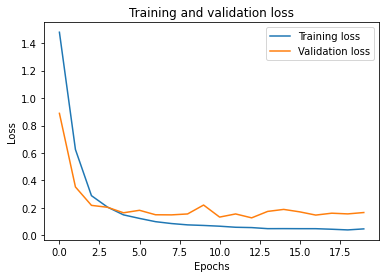

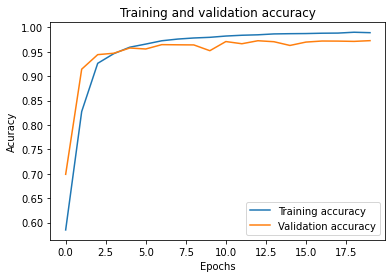

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Acuracy')
plt.legend()
plt.show()


Sometimes, you cannot afford to retrain your model everytime you want to use it, especially if you are limited on computational resources and training your model can take a long time. Therefore, with the Keras library, you can save your model after training. To do that, we use the save method.

In [ ]:
model.save('classification_model.h5')

Since our model contains multidimensional arrays of data, then we usually save them as .h5 files.

When you are ready to use your model again, you use the load_model function from <strong>keras.models</strong>.

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
pretrained_model = load_model('classification_model.h5')

## **Using the model to make predictions**

That is, putting the model to work. In this case, we will predict the clasification scores for one of the inputs used for testing for simplicity, althought new images should be used in a real scenario.

[[4.8208888e-18 7.9313169e-09 1.3214814e-11 9.0981746e-05 3.6361337e-06
  1.9856239e-05 5.0650499e-15 5.0666138e-08 3.5017256e-11 9.9988544e-01]]


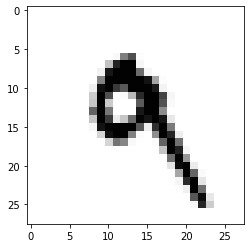

In [ ]:
plt.imshow(X_test[7], cmap='Greys')
prediction = pretrained_model.predict(X_test_flatten[7:8]) # X_test_flatten[7]
print(prediction)

As expected, ``prediction`` takes the highest value for the class"9", and very low values for the rest.

[[1.8215604e-14 3.2553043e-08 1.2338362e-08 2.7319898e-17 9.9995768e-01
  5.6350799e-11 1.7115579e-05 1.5056759e-12 1.8027715e-10 2.5127172e-05]]


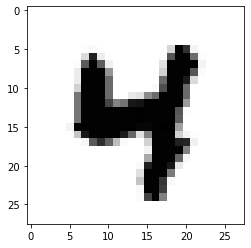

In [ ]:
plt.imshow(X_test[85], cmap='Greys') # AIM
prediction = pretrained_model.predict(X_test_flatten[85:86])
print(prediction)

Part of this notebook has been taken from an edX course. See below reference and license. JG.
<hr>

This notebook is part of a course on **edX** called *Deep Learning Fundamentals with Keras*. If you accessed this notebook outside the course, you can take this course online by clicking [here](http://cocl.us/DL0101EN_edX_Week3_LAB2).

Copyright &copy; 2018 [IBM Developer Skills Network](https://cognitiveclass.ai/?utm_source=bducopyrightlink&utm_medium=dswb&utm_campaign=bdu). This notebook and its source code are released under the terms of the [MIT License](https://bigdatauniversity.com/mit-license/).